<a href="https://colab.research.google.com/github/Keistkmiya/Tugas1-MachineLearning/blob/main/Tugas1_Chapter2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Chapter 2: Supervised Learning

## Setup & Library Imports

In [2]:
!pip install mglearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 16.3 MB/s eta 0:00:00


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import mglearn
from sklearn.model_selection import train_test_split

%matplotlib inline

## Dataset untuk Eksperimen

Kita akan menggunakan dua dataset sederhana ("synthetic datasets") untuk mempermudah visualisasi algoritma:
*   Forge Dataset: Untuk klasifikasi (membedakan dua kelompok titik).
*   Wave Dataset: Untuk regresi (memprediksi nilai kontinu).

X.shape: (26, 2)


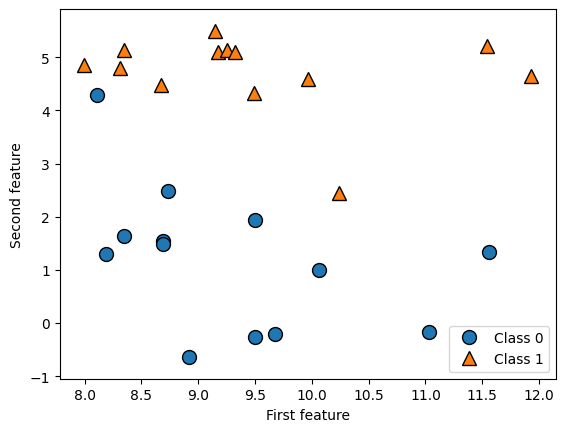

In [4]:
X, y = mglearn.tools.make_handcrafted_dataset()

mglearn.discrete_scatter(X[:, 0], X[:, 1], y)
plt.legend(["Class 0", "Class 1"], loc=4)
plt.xlabel("First feature")
plt.ylabel("Second feature")
print("X.shape: {}".format(X.shape))

### k-NN Classification (k=1)

Lihat bagaimana k-NN bekerja dengan hanya 1 tetangga terdekat. Kita akan menggunakan fungsi visualisasi dari mglearn untuk melihat bagaimana titik-titik baru diberikan label berdasarkan tetangga terdekatnya.

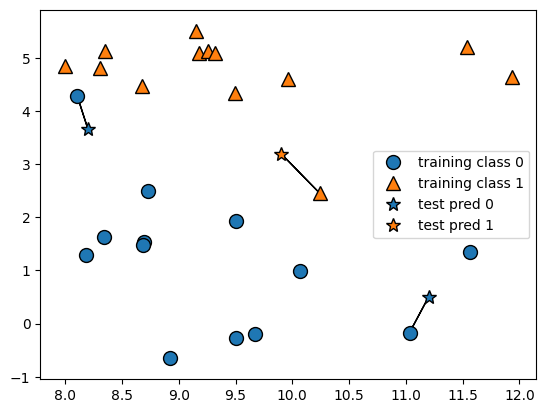

In [5]:
mglearn.plots.plot_knn_classification(n_neighbors=1)

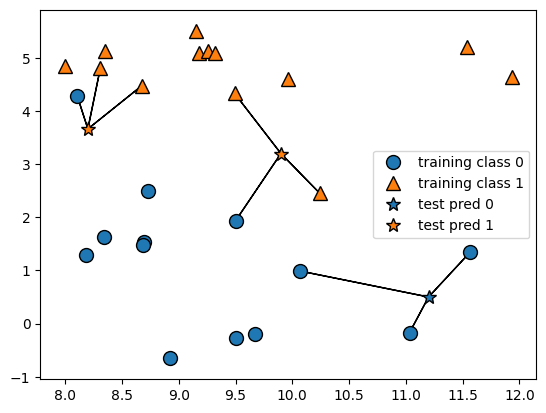

In [6]:
mglearn.plots.plot_knn_classification(n_neighbors=3)

### Melatih KNeighborsClassifier

Sama seperti sebelumnya, kita harus membagi data menjadi *training set* dan *test set* terlebih dahulu sebelum melatih model.

In [7]:
from sklearn.model_selection import train_test_split
X, y = mglearn.datasets.make_forge()

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

from sklearn.neighbors import KNeighborsClassifier
clf = KNeighborsClassifier(n_neighbors=3)

clf.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [8]:
print("Test set predictions: {}".format(clf.predict(X_test)))
print("Test set accuracy: {:.2f}".format(clf.score(X_test, y_test)))

Test set predictions: [1 0 1 0 1 0 0]
Test set accuracy: 0.86


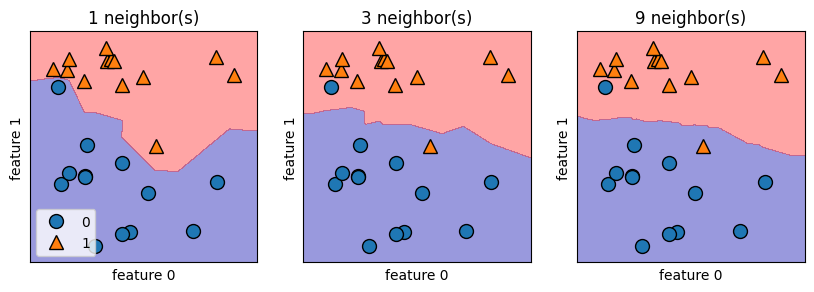

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

for n_neighbors, ax in zip([1, 3, 9], axes):
    clf = KNeighborsClassifier(n_neighbors=n_neighbors).fit(X, y)
    mglearn.plots.plot_2d_separator(clf, X, fill=True, eps=0.5, ax=ax, alpha=.4)
    mglearn.discrete_scatter(X[:, 0], X[:, 1], y, ax=ax)
    ax.set_title("{} neighbor(s)".format(n_neighbors))
    ax.set_xlabel("feature 0")
    ax.set_ylabel("feature 1")
axes[0].legend(loc=3)

### Hubungan Kompleksitas Model dan Generalisasi

Kita akan menguji performa model k-NN pada dataset Breast Cancer dengan mengubah nilai n_neighbors dari 1 sampai 10. Tujuannya adalah mencari titik di mana model tidak terlalu "menghafal" (overfitting) tapi juga tidak terlalu "malas" (underfitting).

In [10]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, stratify=cancer.target, random_state=66)

training_accuracy = []
test_accuracy = []
neighbors_settings = range(1, 11)

for n_neighbors in neighbors_settings:
    clf = KNeighborsClassifier(n_neighbors=n_neighbors)
    clf.fit(X_train, y_train)
    training_accuracy.append(clf.score(X_train, y_train))
    test_accuracy.append(clf.score(X_test, y_test))

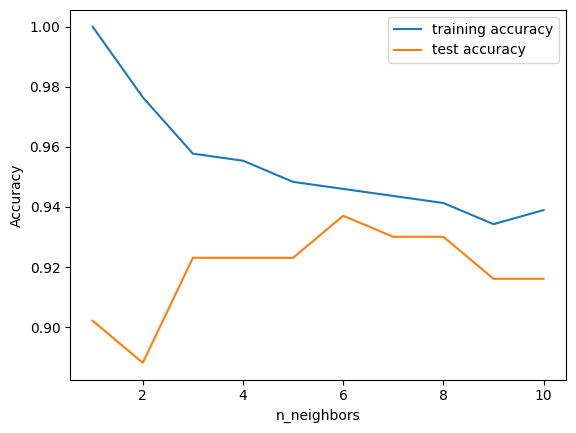

In [11]:
plt.plot(neighbors_settings, training_accuracy, label="training accuracy")
plt.plot(neighbors_settings, test_accuracy, label="test accuracy")
plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.legend()

### k-Neighbors Regression

Kita akan menggunakan dataset Wave untuk melihat bagaimana k-NN memprediksi nilai angka. Algoritma ini bekerja dengan mencari tetangga terdekat dan mengambil nilai rata-rata dari tetangga-tetangga tersebut sebagai hasil prediksinya.

In [12]:
from sklearn.neighbors import KNeighborsRegressor

X, y = mglearn.datasets.make_wave(n_samples=40)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
reg = KNeighborsRegressor(n_neighbors=3)
reg.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=3)

In [13]:
print("Test set predictions:\n{}".format(reg.predict(X_test)))
print("Test set R^2 score: {:.2f}".format(reg.score(X_test, y_test)))

Test set predictions:
[-0.05396539  0.35686046  1.13671923 -1.89415682 -1.13881398 -1.63113382
  0.35686046  0.91241374 -0.44680446 -1.13881398]
Test set R^2 score: 0.83


### Menganalisis KNeighborsRegressor

Kita akan memplot prediksi model untuk semua nilai fitur yang mungkin. Kita akan melihat bagaimana nilai n_neighbors yang berbeda memengaruhi kehalusan garis prediksi.

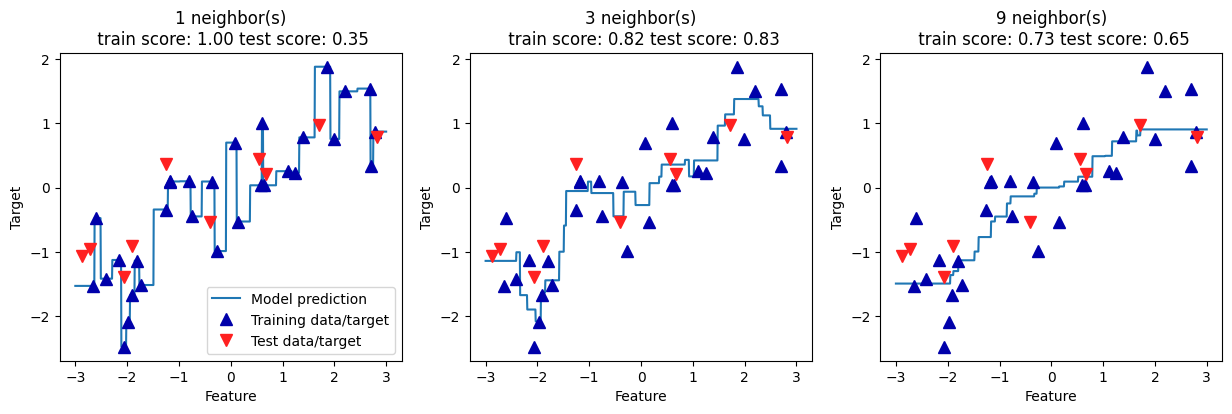

In [14]:
line = np.linspace(-3, 3, 1000).reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for n_neighbors, ax in zip([1, 3, 9], axes):
    reg = KNeighborsRegressor(n_neighbors=n_neighbors)
    reg.fit(X_train, y_train)

    ax.plot(line, reg.predict(line))
    ax.plot(X_train, y_train, '^', c=mglearn.cm2(0), markersize=8)
    ax.plot(X_test, y_test, 'v', c=mglearn.cm2(1), markersize=8)

    ax.set_title(
        "{} neighbor(s)\n train score: {:.2f} test score: {:.2f}".format(
            n_neighbors, reg.score(X_train, y_train),
            reg.score(X_test, y_test)))
    ax.set_xlabel("Feature")
    ax.set_ylabel("Target")

axes[0].legend(["Model prediction", "Training data/target",
                "Test data/target"], loc="best")

# Linear Models
Model linear adalah keluarga algoritma yang melakukan prediksi menggunakan garis lurus untuk regresi, atau bidang datar (hyperplane) untuk klasifikasi.Untuk regresi, rumusnya terlihat seperti ini:$$\hat{y} = w[0] \cdot x[0] + w[1] \cdot x[1] + \dots + w[p] \cdot x[p] + b$$Di sini $w$ adalah *weight* (beban) dan $b$ adalah *bias* (intersep) yang akan dipelajari oleh model.

w[0]: 0.393906  b: -0.031804


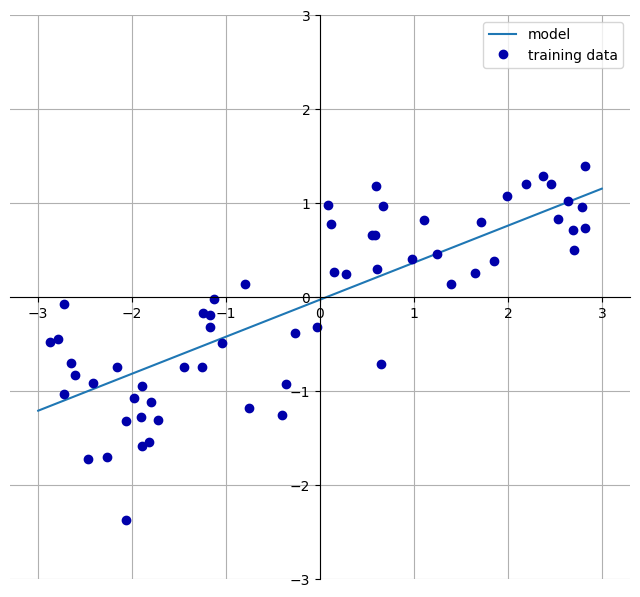

In [15]:
mglearn.plots.plot_linear_regression_wave()

### Linear Regression (OLS)

Kita akan menerapkan Linear Regression pada dataset Wave. Model ini tidak memiliki parameter tambahan (seperti n_neighbors pada k-NN), sehingga kita tidak bisa mengontrol kompleksitas modelnya secara langsung.

In [16]:
from sklearn.linear_model import LinearRegression
X, y = mglearn.datasets.make_wave(n_samples=60)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

lr = LinearRegression().fit(X_train, y_train)

In [17]:
print("lr.coef_: {}".format(lr.coef_))
print("lr.intercept_: {}".format(lr.intercept_))

lr.coef_: [0.39390555]
lr.intercept_: -0.031804343026759746


In [18]:
print("Training set score: {:.2f}".format(lr.score(X_train, y_train)))
print("Test set score: {:.2f}".format(lr.score(X_test, y_test)))

Training set score: 0.67
Test set score: 0.66


### Linear Regression pada Dataset Kompleks

Kita akan menggunakan dataset Boston Housing yang sudah diperluas (extended). Dataset ini memiliki 105 fitur. Kita akan melihat bagaimana performa OLS jika dihadapkan pada banyak dimensi.

In [19]:
X, y = mglearn.datasets.load_extended_boston()

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
lr = LinearRegression().fit(X_train, y_train)

In [20]:
print("Training set score: {:.2f}".format(lr.score(X_train, y_train)))
print("Test set score: {:.2f}".format(lr.score(X_test, y_test)))

Training set score: 0.95
Test set score: 0.61


### Ridge Regression
Ridge regression menggunakan teknik L2 regularization. Tujuannya adalah meminimalkan Mean Squared Error PLUS penalti dari kuadrat koefisien:$$\text{} \sum (y - \hat{y})^2 + \alpha \sum w^2$$Parameter alpha mengontrol seberapa kuat penalti tersebut. Semakin besar alpha, semakin "datar" model kita (koefisien mendekati nol).

In [21]:
from sklearn.linear_model import Ridge

ridge = Ridge().fit(X_train, y_train)
print("Training set score: {:.2f}".format(ridge.score(X_train, y_train)))
print("Test set score: {:.2f}".format(ridge.score(X_test, y_test)))

Training set score: 0.89
Test set score: 0.75


####Eksperimen

In [22]:
ridge10 = Ridge(alpha=10).fit(X_train, y_train)
print("Ridge alpha=10 - Training: {:.2f}, Test: {:.2f}".format(
    ridge10.score(X_train, y_train), ridge10.score(X_test, y_test)))

ridge01 = Ridge(alpha=0.1).fit(X_train, y_train)
print("Ridge alpha=0.1 - Training: {:.2f}, Test: {:.2f}".format(
    ridge01.score(X_train, y_train), ridge01.score(X_test, y_test)))

Ridge alpha=10 - Training: 0.79, Test: 0.64
Ridge alpha=0.1 - Training: 0.93, Test: 0.77


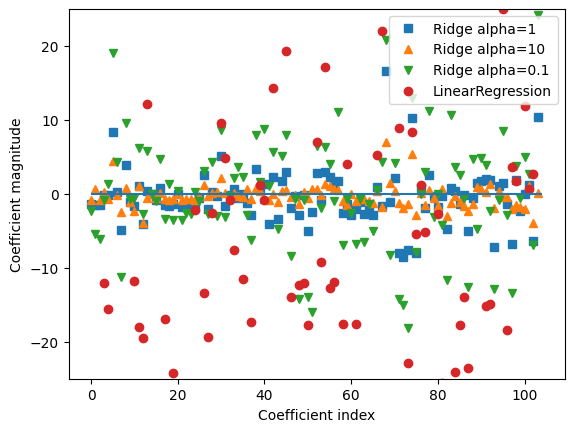

In [23]:
plt.plot(ridge.coef_, 's', label="Ridge alpha=1")
plt.plot(ridge10.coef_, '^', label="Ridge alpha=10")
plt.plot(ridge01.coef_, 'v', label="Ridge alpha=0.1")

plt.plot(lr.coef_, 'o', label="LinearRegression")
plt.xlabel("Coefficient index")
plt.ylabel("Coefficient magnitude")
plt.hlines(0, 0, len(lr.coef_))
plt.ylim(-25, 25)
plt.legend()

### Lasso Regression
Sama seperti Ridge, Lasso juga membatasi koefisien agar mendekati nol. Namun, Lasso punya "kekuatan super": ia bisa memaksa beberapa koefisien menjadi tepat nol. Artinya, Lasso secara otomatis melakukan seleksi fitur (mengabaikan fitur yang tidak penting). Rumus penaltinya menggunakan nilai absolut:$$\text{} \sum (y - \hat{y})^2 + \alpha \sum |w|$$

In [24]:
from sklearn.linear_model import Lasso

lasso = Lasso().fit(X_train, y_train)
print("Training set score: {:.2f}".format(lasso.score(X_train, y_train)))
print("Test set score: {:.2f}".format(lasso.score(X_test, y_test)))
print("Number of features used: {}".format(np.sum(lasso.coef_ != 0)))

Training set score: 0.29
Test set score: 0.21
Number of features used: 4


### Menala Lasso (Tuning Lasso)

Kita akan mencoba menurunkan nilai alpha menjadi 0.01. Dengan menurunkan alpha, kita membiarkan model menggunakan lebih banyak fitur untuk mencoba menangkap pola yang lebih kompleks.

In [25]:
lasso001 = Lasso(alpha=0.01, max_iter=100000).fit(X_train, y_train)

print("Lasso alpha=0.01 - Training set score: {:.2f}".format(lasso001.score(X_train, y_train)))
print("Lasso alpha=0.01 - Test set score: {:.2f}".format(lasso001.score(X_test, y_test)))
print("Number of features used: {}".format(np.sum(lasso001.coef_ != 0)))

Lasso alpha=0.01 - Training set score: 0.90
Lasso alpha=0.01 - Test set score: 0.77
Number of features used: 33


Text(0, 0.5, 'Coefficient magnitude')

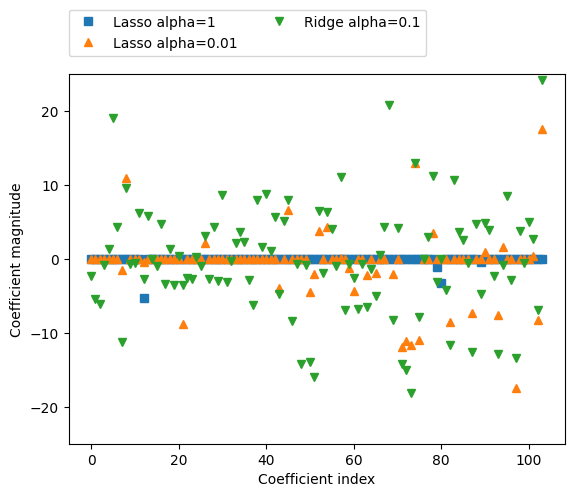

In [26]:
plt.plot(lasso.coef_, 's', label="Lasso alpha=1")
plt.plot(lasso001.coef_, '^', label="Lasso alpha=0.01")
plt.plot(ridge01.coef_, 'v', label="Ridge alpha=0.1")

plt.ylim(-25, 25)
plt.legend(ncol=2, loc=(0, 1.05))
plt.xlabel("Coefficient index")
plt.ylabel("Coefficient magnitude")

#Linear Models for Classification
Dua algoritma klasifikasi linear yang paling populer adalah:


*   Logistic Regression
*   Linear Support Vector Machines (Linear SVC)


Keduanya bekerja dengan cara mencari garis pemisah (atau decision boundary) yang terbaik untuk memisahkan kelas-kelas data. Jika data berada di atas garis, ia masuk Kelas A; jika di bawah garis, ia masuk Kelas B.

## Klasifikasi Linear

Kita akan membandingkan visualisasi antara Logistic Regression dan Linear SVC pada dataset forge.

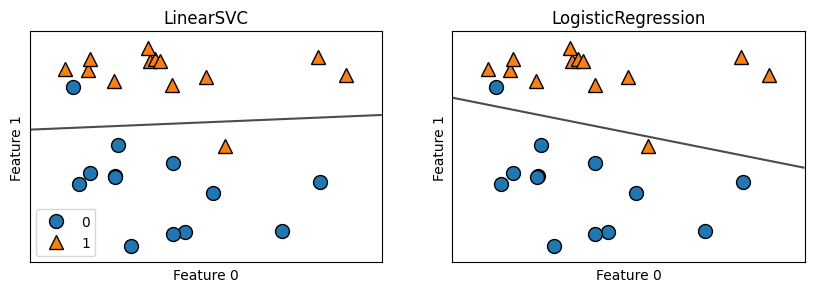

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

X, y = mglearn.datasets.make_forge()

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

for model, ax in zip([LinearSVC(max_iter=10000), LogisticRegression()], axes):
    clf = model.fit(X, y)
    mglearn.plots.plot_2d_separator(clf, X, fill=False, eps=0.5,
                                    ax=ax, alpha=.7)
    mglearn.discrete_scatter(X[:, 0], X[:, 1], y, ax=ax)
    ax.set_title("{}".format(clf.__class__.__name__))
    ax.set_xlabel("Feature 0")
    ax.set_ylabel("Feature 1")
axes[0].legend()

### Pengaruh Parameter C pada LinearSVC

Pada grafik di bawah, kita akan membandingkan tiga nilai C yang berbeda: 0.01, 10, dan 1000. Perhatikan bagaimana garis pemisah (decision boundary) berubah untuk mencoba mengakomodasi titik-titik data yang sulit diklasifikasikan.

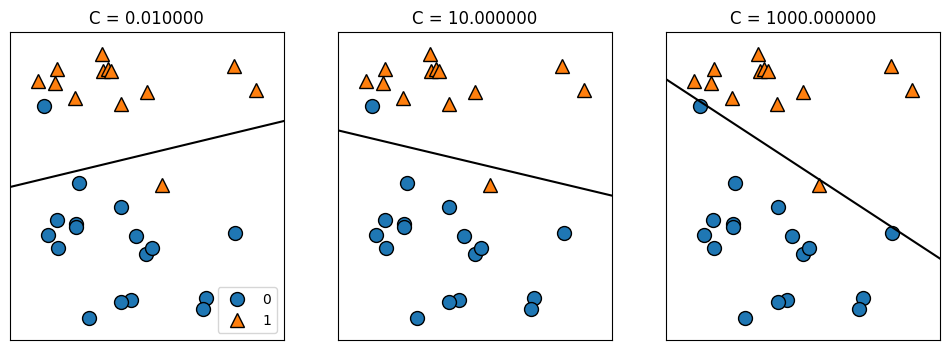

In [28]:
mglearn.plots.plot_linear_svc_regularization()

In [29]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, stratify=cancer.target, random_state=42)

logreg = LogisticRegression(max_iter=10000).fit(X_train, y_train)
print("Training set score: {:.3f}".format(logreg.score(X_train, y_train)))
print("Test set score: {:.3f}".format(logreg.score(X_test, y_test)))

Training set score: 0.958
Test set score: 0.958
